<a href="https://colab.research.google.com/github/deepaksuthar18/sentiment_analysis_using_transformer/blob/main/sentiment_analysis_using_roberta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install dependency

In [ ]:
!pip install -q transformers[torch] datasets evaluate accelerate scikit-learn pandas tqdm pyyaml joblib matplotlib seaborn


# Imports and Setup

In [ ]:
import os
import re
import sys
import yaml
import logging
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, List, Union, Dict, Tuple
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
import joblib

# Setup logging to show in Colab
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger("ColabSentiment")

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: GPU not detected. Training will be slow. Go to Runtime -> Change runtime type -> Hardware accelerator -> GPU.")


Using device: cuda


# Dataset Upload

In [ ]:
from google.colab import files
import os

if not os.path.exists('processed_dataset'):
    os.makedirs('processed_dataset')

print("Please upload 'cleaned_twitter_training.csv' and 'cleaned_twitter_validation.csv' to 'processed_dataset' folder or use the upload button below.")
uploaded = files.upload()

for filename in uploaded.keys():
    # If the file is already in a folder, handle it
    dest_path = os.path.join('processed_dataset', os.path.basename(filename))
    with open(dest_path, "wb") as f:
        f.write(uploaded[filename])
    print(f"Saved {filename} to processed_dataset/")


Please upload 'cleaned_twitter_training.csv' and 'cleaned_twitter_validation.csv' to 'processed_dataset' folder or use the upload button below.


Saving cleaned_twitter_training.csv to cleaned_twitter_training.csv
Saving cleaned_twitter_validation.csv to cleaned_twitter_validation.csv
Saved cleaned_twitter_training.csv to processed_dataset/
Saved cleaned_twitter_validation.csv to processed_dataset/


# Configuration

In [ ]:
config_dict = {
    'paths': {
        'train_data': "processed_dataset/cleaned_twitter_training.csv",
        'val_data': "processed_dataset/cleaned_twitter_validation.csv",
        'processed_dir': "processed_dataset",
        'logs_path': "logs",
        'model_save_dir': "models/roberta_sentiment"
    },
    'data_loader': {
        'columns': ["sentiment", "text"],
        'target_column': "sentiment",
        'text_column': "text",
        'has_header': True
    },
    'model_params': {
        'model_name': "cardiffnlp/twitter-roberta-base-sentiment-latest",
        'batch_size': 16,
        'learning_rate': 2e-5,
        'epochs': 4,
        'max_length': 128,
        'weight_decay': 0.01,
        'eval_steps': 100,
        'logging_steps': 50,
        'positive_threshold': 0.6,
        'negative_threshold': 0.4
    }
}

# Ensure directories exist
for path_val in config_dict['paths'].values():
    if '_dir' in path_val or '_path' in path_val or '/' in path_val:
        dir_path = os.path.dirname(path_val) if '.' in os.path.basename(path_val) else path_val
        if dir_path and not os.path.exists(dir_path):
            os.makedirs(dir_path)


# Preprocessing and Data Loading

In [ ]:
class SentimentPreprocessor:
    def __init__(self):
        pass

    def clean_text(self, text: str) -> str:
        if not isinstance(text, str): return ""
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'\@\w+', '', text)
        text = re.sub(r'#(\w+)', r'\1', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def preprocess_series(self, series: List[str]) -> List[str]:
        return [self.clean_text(text) for text in tqdm(series, desc="Cleaning text")]

class DataLoader:
    def __init__(self, config: dict):
        self.config = config
        self.columns = config['data_loader']['columns']
        self.target_col = config['data_loader']['target_column']
        self.text_col = config['data_loader']['text_column']

    def load_data(self, data_type: str = "train") -> pd.DataFrame:
        path_key = 'train_data' if data_type == "train" else 'val_data'
        file_path = self.config['paths'][path_key]

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Missing file: {file_path}")

        has_header = self.config['data_loader'].get('has_header', False)
        header_val = 0 if has_header else None
        names_val = None if has_header else self.columns

        try:
            df = pd.read_csv(file_path, names=names_val, header=header_val, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(file_path, names=names_val, header=header_val, encoding='ISO-8859-1')

        df = df.dropna(subset=[self.text_col, self.target_col])
        return df

    def get_train_val_split(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        return self.load_data("train"), self.load_data("val")


#  Model and Evaluation

In [ ]:
class ModelEvaluator:
    @staticmethod
    def evaluate(y_true, y_pred, labels=None, output_dir: str = "logs"):
        acc = accuracy_score(y_true, y_pred)
        report = classification_report(y_true, y_pred, target_names=[str(l) for l in labels])
        print(f"\nAccuracy: {acc:.4f}")
        print("\nClassification Report:\n", report)

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
        plt.show()

        return {"accuracy": acc, "report": report}

class SentimentModel:
    def __init__(self, model_name: str, num_labels: int = 3):
        self.model_name = model_name
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.label_encoder = LabelEncoder()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels, ignore_mismatched_sizes=True
        ).to(self.device)

    def _tokenize_function(self, examples):
        return self.tokenizer(examples["text"], truncation=True, padding=False, max_length=128)

    def train(self, X_train, y_train, X_val, y_val, training_args_dict):
        y_encoded = self.label_encoder.fit_transform(y_train)
        num_labels = len(self.label_encoder.classes_)

        if num_labels != self.model.config.num_labels:
            self.model = AutoModelForSequenceClassification.from_pretrained(
                self.model_name, num_labels=num_labels, ignore_mismatched_sizes=True
            ).to(self.device)

        train_dataset = Dataset.from_dict({"text": X_train, "label": y_encoded})
        train_dataset = train_dataset.map(self._tokenize_function, batched=True)

        y_val_encoded = self.label_encoder.transform(y_val)
        val_dataset = Dataset.from_dict({"text": X_val, "label": y_val_encoded})
        val_dataset = val_dataset.map(self._tokenize_function, batched=True)

        training_args = TrainingArguments(**training_args_dict)
        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            tokenizer=self.tokenizer,
            data_collator=DataCollatorWithPadding(tokenizer=self.tokenizer),
        )
        trainer.train()

    def predict(self, X: List[str], batch_size: int = 32) -> List[str]:
        self.model.eval()
        all_predictions = []
        for i in tqdm(range(0, len(X), batch_size), desc="Predicting Sentiment"):
            batch_texts = X[i : i + batch_size]
            inputs = self.tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=128).to(self.device)
            with torch.no_grad():
                outputs = self.model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            all_predictions.extend(predictions)
        return self.label_encoder.inverse_transform(all_predictions).tolist()

    def save(self, directory: str):
        if not os.path.exists(directory): os.makedirs(directory)
        self.model.save_pretrained(directory)
        self.tokenizer.save_pretrained(directory)
        joblib.dump(self.label_encoder, os.path.join(directory, "label_encoder.joblib"))


# Pipeline Orchestration

In [ ]:
class SentimentPipeline:
    def __init__(self, config: dict):
        self.config = config
        self.loader = DataLoader(config)
        self.preprocessor = SentimentPreprocessor()
        model_name = config['model_params'].get('model_name')
        self.model = SentimentModel(model_name=model_name)

    def run_training_pipeline(self):
        train_df, val_df = self.loader.get_train_val_split()

        train_texts = self.preprocessor.preprocess_series(train_df[self.loader.text_col].tolist())
        val_texts = self.preprocessor.preprocess_series(val_df[self.loader.text_col].tolist())

        y_train = train_df[self.loader.target_col].tolist()
        y_val = val_df[self.loader.target_col].tolist()

        model_params = self.config['model_params']
        training_args = {
            "output_dir": "./results",
            "per_device_train_batch_size": model_params.get("batch_size", 16),
            "per_device_eval_batch_size": model_params.get("batch_size", 16),
            "learning_rate": float(model_params.get("learning_rate", 2e-5)),
            "num_train_epochs": model_params.get("epochs", 3),
            "weight_decay": model_params.get("weight_decay", 0.01),
            "logging_steps": model_params.get("logging_steps", 50),
            "eval_steps": model_params.get("eval_steps", 100),
            "eval_strategy": "steps",
            "load_best_model_at_end": True,
            "save_total_limit": 2,
            "report_to": "none"
        }

        self.model.train(train_texts, y_train, val_texts, y_val, training_args)

        print("\nRunning Predict on Validation set...")
        y_pred = self.model.predict(val_texts)

        labels = sorted(list(set(y_train)))
        eval_results = ModelEvaluator.evaluate(y_val, y_pred, labels=labels)

        model_dir = self.config['paths'].get('model_save_dir', 'models/roberta_sentiment')
        self.model.save(model_dir)
        return eval_results


# Execute Pipeline

In [ ]:
class ModelEvaluator:
    @staticmethod
    def evaluate(y_true, y_pred, labels=None, output_dir: str = "logs"):
        acc = accuracy_score(y_true, y_pred)
        report = classification_report(y_true, y_pred, target_names=[str(l) for l in labels])
        print(f"\nAccuracy: {acc:.4f}")
        print("\nClassification Report:\n", report)

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
        plt.show()

        return {"accuracy": acc, "report": report}

class SentimentModel:
    def __init__(self, model_name: str, num_labels: int = 3):
        self.model_name = model_name
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.label_encoder = LabelEncoder()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels, ignore_mismatched_sizes=True
        ).to(self.device)

    def _tokenize_function(self, examples):
        return self.tokenizer(examples["text"], truncation=True, padding=False, max_length=128)

    def train(self, X_train, y_train, X_val, y_val, training_args_dict):
        y_encoded = self.label_encoder.fit_transform(y_train)
        num_labels = len(self.label_encoder.classes_)

        if num_labels != self.model.config.num_labels:
            self.model = AutoModelForSequenceClassification.from_pretrained(
                self.model_name, num_labels=num_labels, ignore_mismatched_sizes=True
            ).to(self.device)

        train_dataset = Dataset.from_dict({"text": X_train, "label": y_encoded})
        train_dataset = train_dataset.map(self._tokenize_function, batched=True)

        y_val_encoded = self.label_encoder.transform(y_val)
        val_dataset = Dataset.from_dict({"text": X_val, "label": y_val_encoded})
        val_dataset = val_dataset.map(self._tokenize_function, batched=True)

        training_args = TrainingArguments(**training_args_dict)
        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=DataCollatorWithPadding(tokenizer=self.tokenizer),
        )
        trainer.train()

    def predict(self, X: List[str], batch_size: int = 32) -> List[str]:
        self.model.eval()
        all_predictions = []
        for i in tqdm(range(0, len(X), batch_size), desc="Predicting Sentiment"):
            batch_texts = X[i : i + batch_size]
            inputs = self.tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=128).to(self.device)
            with torch.no_grad():
                outputs = self.model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            all_predictions.extend(predictions)
        return self.label_encoder.inverse_transform(all_predictions).tolist()

    def save(self, directory: str):
        if not os.path.exists(directory): os.makedirs(directory)
        self.model.save_pretrained(directory)
        self.tokenizer.save_pretrained(directory)
        joblib.dump(self.label_encoder, os.path.join(directory, "label_encoder.joblib"))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SentimentPipeline initialized successfully.
Starting sentiment training pipeline...


Cleaning text: 100%|██████████| 1000/1000 [00:00<00:00, 16764.27it/s]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Running Predict on Validation set...


Predicting Sentiment: 100%|██████████| 32/32 [00:05<00:00,  6.39it/s]



Accuracy: 0.9510

Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.95      0.92      0.94       172
    Negative       0.98      0.97      0.97       266
     Neutral       0.95      0.93      0.94       285
    Positive       0.93      0.97      0.95       277

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



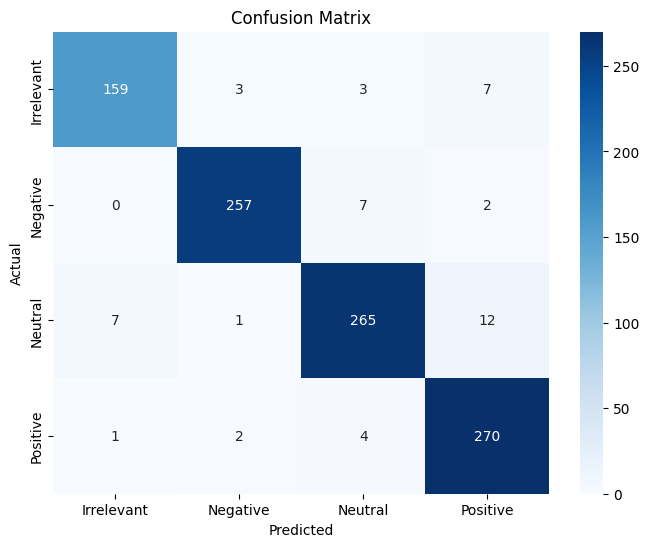

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Sentiment training pipeline finished.
Final evaluation results: {'accuracy': 0.951, 'report': '              precision    recall  f1-score   support\n\n  Irrelevant       0.95      0.92      0.94       172\n    Negative       0.98      0.97      0.97       266\n     Neutral       0.95      0.93      0.94       285\n    Positive       0.93      0.97      0.95       277\n\n    accuracy                           0.95      1000\n   macro avg       0.95      0.95      0.95      1000\nweighted avg       0.95      0.95      0.95      1000\n'}


In [ ]:
try:
    pipeline = SentimentPipeline(config_dict)
    print("SentimentPipeline initialized successfully.")
    print("Starting sentiment training pipeline...")
    eval_results = pipeline.run_training_pipeline()
    print("Sentiment training pipeline finished.")
    print(f"Final evaluation results: {eval_results}")
except Exception as e:
    print(f"Error during pipeline execution: {e}")

Validation DataFrame loaded with 1000 rows.


Cleaning text: 100%|██████████| 1000/1000 [00:00<00:00, 41275.61it/s]


Validation texts preprocessed. First 5: ['I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣', "BBC News - Amazon boss Jeff Bezos rejects claims company acted like a 'drug dealer' bbc.co.uk/news/av/busine…", 'Why do I pay for WORD when it functions so poorly on my Chromebook? 🙄', "CSGO matchmaking is so full of closet hacking, it's a truly awful game.", 'Now the President is slapping Americans in the face that he really did commit an unlawful act after his acquittal! From Discover on Google vanityfair.com/news/2020/02/t…']


Predicting Sentiment: 100%|██████████| 32/32 [00:05<00:00,  5.68it/s]
/tmp/ipython-input-367/3121939086.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')


Sentiment predictions generated. First 5: ['Irrelevant', 'Neutral', 'Negative', 'Negative', 'Neutral']
Predicted sentiment distribution:
 Positive      291
Neutral       279
Negative      263
Irrelevant    167
Name: count, dtype: int64


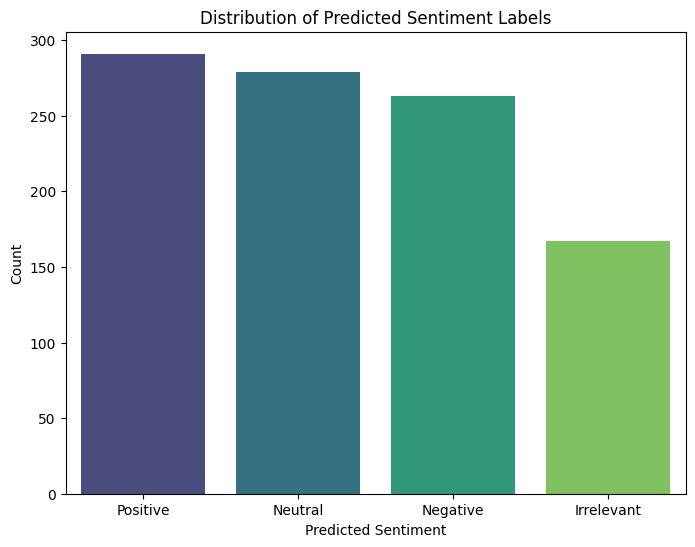

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the validation dataset
val_df = pipeline.loader.load_data("val")
print(f"Validation DataFrame loaded with {len(val_df)} rows.")

# 2. Extract the text column and preprocess it
val_texts = pipeline.preprocessor.preprocess_series(val_df[pipeline.loader.text_col].tolist())
print(f"Validation texts preprocessed. First 5: {val_texts[:5]}")

# 3. Generate sentiment predictions
y_pred = pipeline.model.predict(val_texts)
print(f"Sentiment predictions generated. First 5: {y_pred[:5]}")

# 4. Convert the y_pred list into a pandas Series
y_pred_series = pd.Series(y_pred)

# 5. Calculate the value counts of each predicted sentiment label
sentiment_distribution = y_pred_series.value_counts()
print("Predicted sentiment distribution:\n", sentiment_distribution)

# 6. Create a bar chart of these value counts
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')
plt.title('Distribution of Predicted Sentiment Labels')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Count')
plt.show()
